In [1]:
import matplotlib.pyplot as plt
import lusee
import numpy as np
import healpy as hp
import astropy.units as u
import astropy.constants as const

# Foregrounds vs. Signal
As our foreground template, we'll use the ULSA maps from 1-50 MHz, provided as maps of brightness temperature.

Text(0.0, -1.4, '$\\log_{10}(T/K)$')

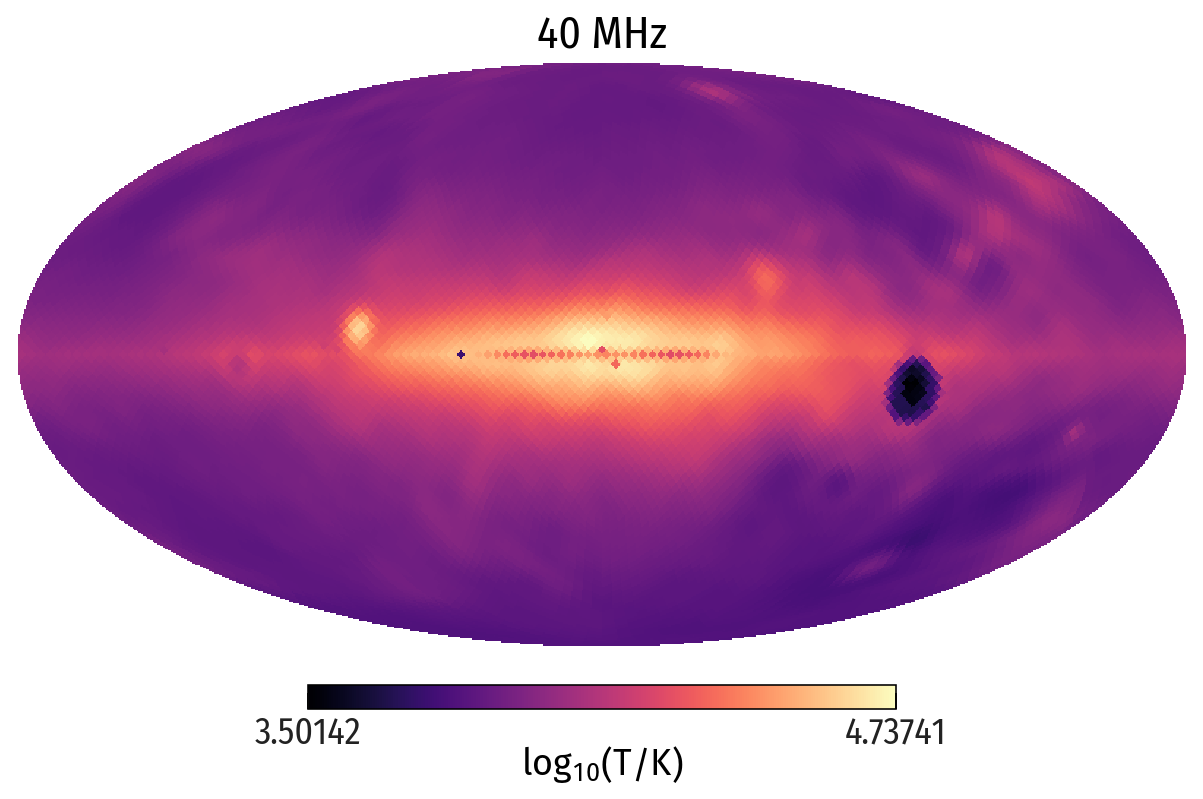

In [2]:
# read in ULSA map just for plotting in this cell
ULSA_NSIDE = 32
T_sky = lusee.sky.FitsSky("../simulation/sky_data/ULSA_32_ddi_smooth.fits",lmax=1)

hp.mollview(np.log10(T_sky.maps[39]),title=f"{39+1} MHz")
plt.text(0.0, -1.4, "$\log_{10}(T/K)$", fontsize=18, ha='center', va='center')

The CMB is a blackbody at 2.725 K, and its specific intensity $B_{\nu}$ is given by Planck's equation,
$$B_{\nu}(\nu, T) = \frac{2 h \nu^3}{c^2} \frac{1}{\exp \left( \frac{h \nu}{kT}\right) - 1}.$$

In [3]:
T_CMB = 2.725 * u.K

def blackbody(nu, T):
    """blackbody radiation specific intensity"""
    B = 2 * const.h * nu**3 / const.c**2 / np.expm1( const.h * nu / (const.k_B * T) )
    return B.to(u.W / u.m / u.m / u.Hz)

lusee.monosky.B2T(blackbody(40 * u.MHz, T_CMB).value, 40)  # we are in RJ tail so T_b ~ T_CMB

<Quantity 2.72404026 K>

In [4]:
high_latitude_pixels = hp.query_strip(ULSA_NSIDE, np.pi/2 + np.pi/6, np.pi/2 - np.pi/6)

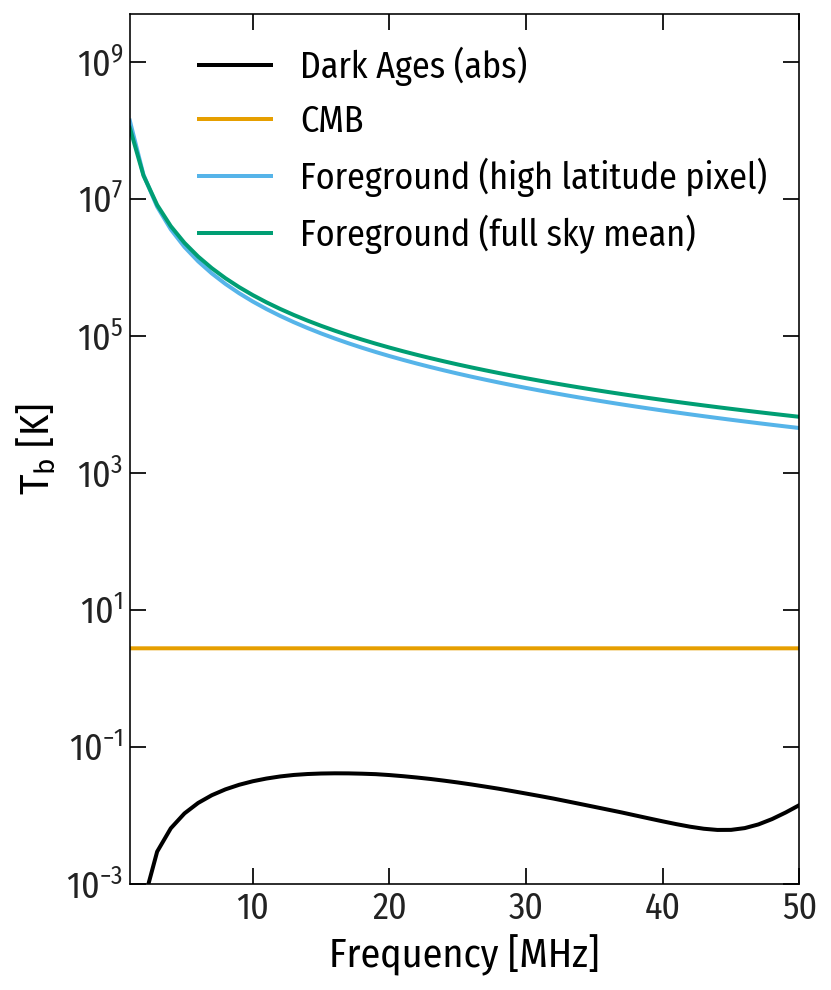

In [5]:
plt.figure(figsize=(6,8))

plt.plot(T_sky.freq_list, np.abs(lusee.monosky.T_DarkAges(T_sky.freq_list)), "-", label="Dark Ages (abs)")
plt.plot(T_sky.freq_list, lusee.monosky.B2T(blackbody(T_sky.freq_list * u.MHz, 2.725 * u.K).value, T_sky.freq_list), "-", label="CMB" )
plt.plot(T_sky.freq_list, [m[high_latitude_pixels[0]] for m in T_sky.maps], "-", label="Foreground (high latitude pixel)")
plt.plot(T_sky.freq_list, [np.mean(m) for m in T_sky.maps], "-", label="Foreground (full sky mean)")

plt.yscale("log")
plt.ylim(1e-3, 5e9)
plt.xlim(1,50)
plt.ylabel("$T_b$ [K]")
plt.xlabel("Frequency [MHz]")
plt.legend()


Let's imagine a perfect instrument that gets a low-resolution view of the sky.
The ULSA maps are relatively high-resolution compared to what LuSEE will probably be able to measure. Thus, our first step is to go to lower resolution with `ud_grade`. 

<!-- In addition, the ULSA maps are specified in terms of brightness temperature. We convert the maps to specific intensity in Jy/sr, via
$$ I_{\nu} = \frac{2 k }{c^2} \nu^2 T_b .$$ -->

Text(0.0, -1.4, '$\\log_{10}(T/K)$')

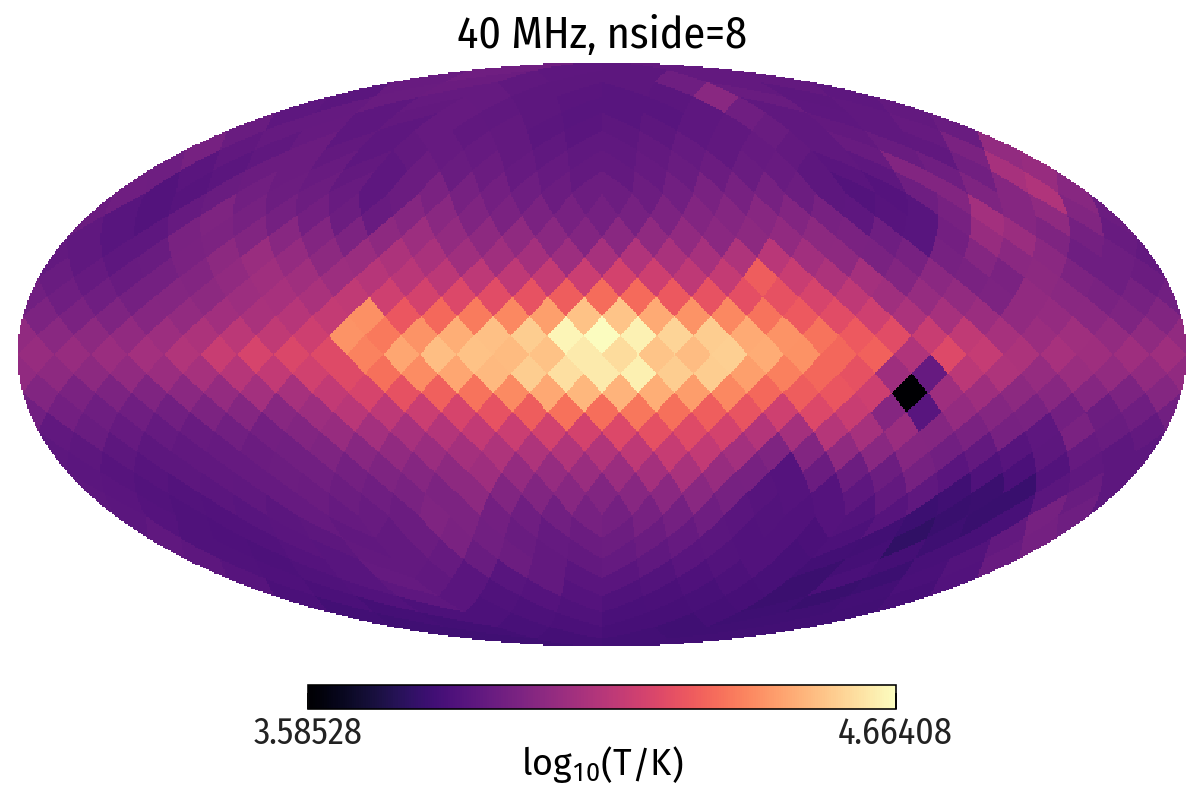

In [6]:
test_sky = lusee.sky.FitsSky("../simulation/sky_data/ULSA_32_ddi_smooth.fits",lmax=1)
nside_out = 8
newskymaps = np.zeros((len(test_sky.freq_list), hp.nside2npix(nside_out)))

for i in range(len(test_sky.maps)):
    nu = test_sky.freq_list[i]
    newskymaps[i] = hp.ud_grade(test_sky.maps[i], nside_out)
test_sky.maps = newskymaps
hp.mollview(np.log10(test_sky.maps[39]), title=f"{39+1} MHz, nside={nside_out}")
plt.text(0.0, -1.4, "$\log_{10}(T/K)$", fontsize=18, ha='center', va='center')

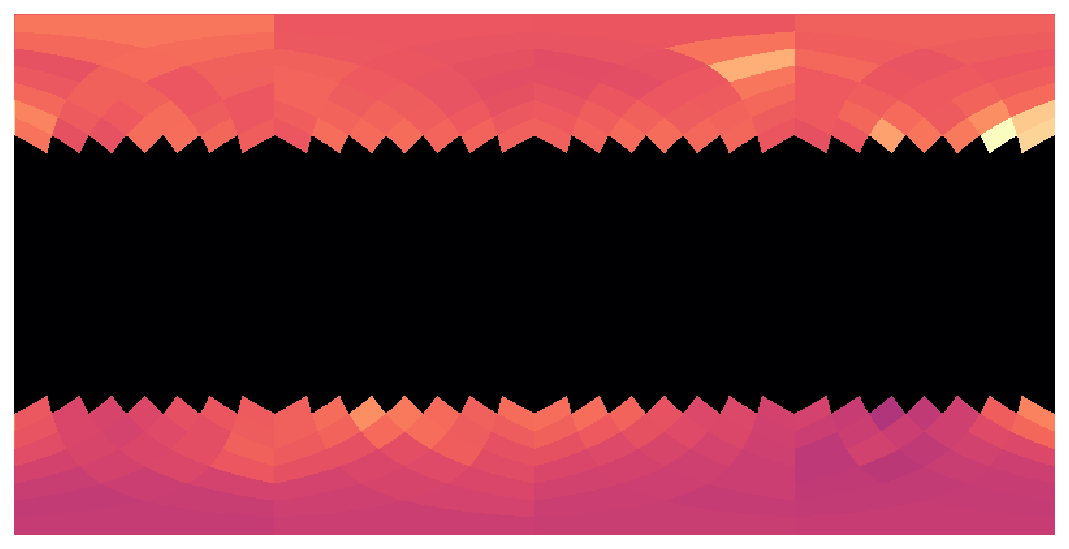

In [7]:
high_latitude_pixels = hp.query_strip(nside_out, np.pi/2 + np.pi/4, np.pi/2 - np.pi/4)
test_map = np.zeros(hp.nside2npix(nside_out))
test_map[high_latitude_pixels] = test_sky.maps[39][high_latitude_pixels]
hp.cartview(test_map,title=None, cbar=False)

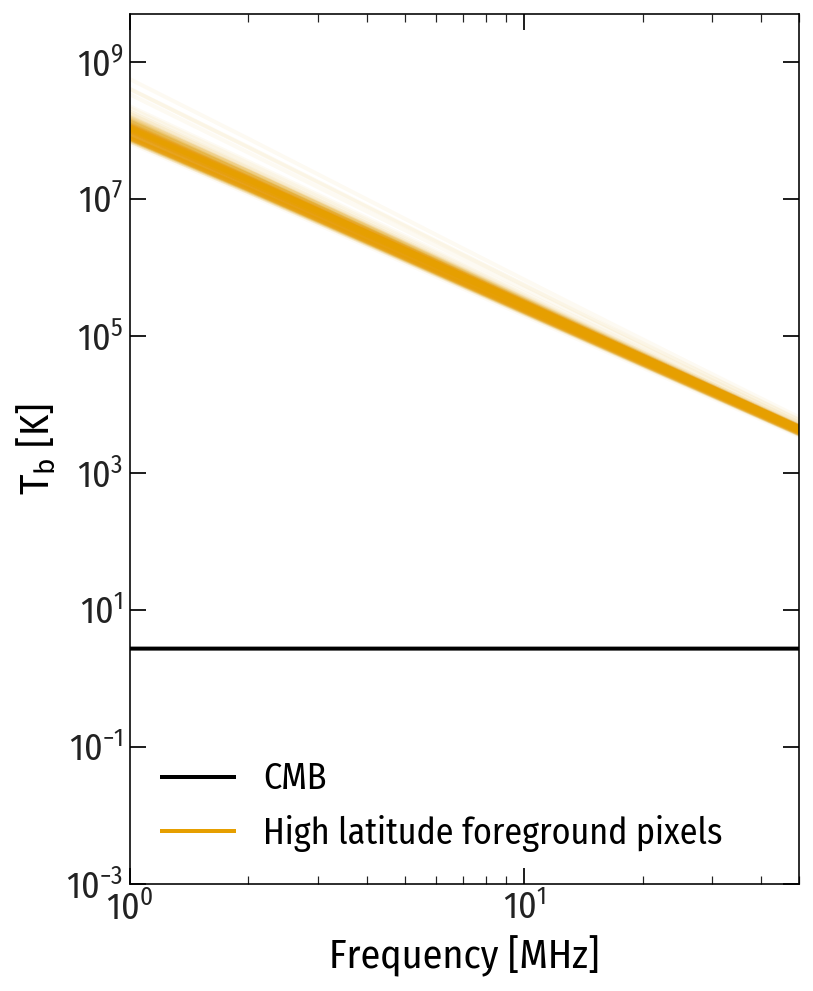

In [8]:
plt.figure(figsize=(6,8))

plt.plot(test_sky.freq_list, lusee.monosky.B2T(blackbody(test_sky.freq_list * u.MHz, 2.725 * u.K).value, test_sky.freq_list), "-", label="CMB" )

for pix in high_latitude_pixels:
    plt.plot(test_sky.freq_list, [m[pix] for m in test_sky.maps], "-", color="C1", alpha=0.05)
plt.plot([], [], "-", label="High latitude foreground pixels", color="C1")

plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-3, 5e9)
plt.xlim(1,50)
plt.xlabel("Frequency [MHz]")
plt.ylabel("$T_b$ [K]")
plt.legend()

# Fitting Some Power Laws
One could at this point attempt to do a Fisher analysis, via something like the radiometer equation that takes into account bandwidths and integration times. However, we can do a very dumb analysis and fit a simple power law model for each pixel,
$$ t(\nu) = A_i (\nu / \nu_*)^{-\alpha_i} + 2.725 \text{ K} + \Delta T_{cmb}. $$
This kind of analysis, which uses spectral information but no spatial information, tells us about the effect of model error. We choose here $\nu_* = 1$ MHz for simplicity.

In [9]:
from scipy.optimize import curve_fit


freqs = test_sky.freq_list
cut = freqs > 1

def cmb_brightness(nu):
    return lusee.monosky.B2T(blackbody(nu * u.MHz, T_CMB).value, nu).value

# log of powerlaw for easy of fitting
def powerlaw_model(nu, A, alpha, deltaTcmb):
    return np.log((A * nu**alpha + 2.725 + deltaTcmb))

def fit(pix, plot=False):
    xl, yl = test_sky.freq_list[cut], np.array([m[pix] + 2.725 for nu, m in zip(test_sky.freq_list[cut], test_sky.maps[cut])])
    popt, pcov = curve_fit(powerlaw_model, xl, np.log(yl), [1e8, -2.58, 0.0], bounds=np.array([[0.0, np.inf], [-5.0, 0.0], [-500.0, 500.0]]).T)

    if plot:
        fig, axes = plt.subplots(2,1, figsize=(4,6))
        axes[0].plot(xl, powerlaw_model(xl, *popt), "-")
        axes[0].plot(xl, np.log(yl), ".")
        axes[1].plot(xl, np.log(yl) - powerlaw_model(xl, *popt), ".")
        # axes[0].set_yscale("log")
        axes[0].set_ylabel("fit")
        axes[1].set_ylabel("resid")
        plt.xlabel("Frequency [MHz]")
        print(popt, "error:", np.sqrt(pcov[-1,-1]))

    return popt[-1], np.sqrt(pcov[-1,-1])

[ 1.45512411e+08 -2.65351407e+00  3.04749671e+01] error: 1.9397763301476816


(30.474967101857494, 1.9397763301476816)

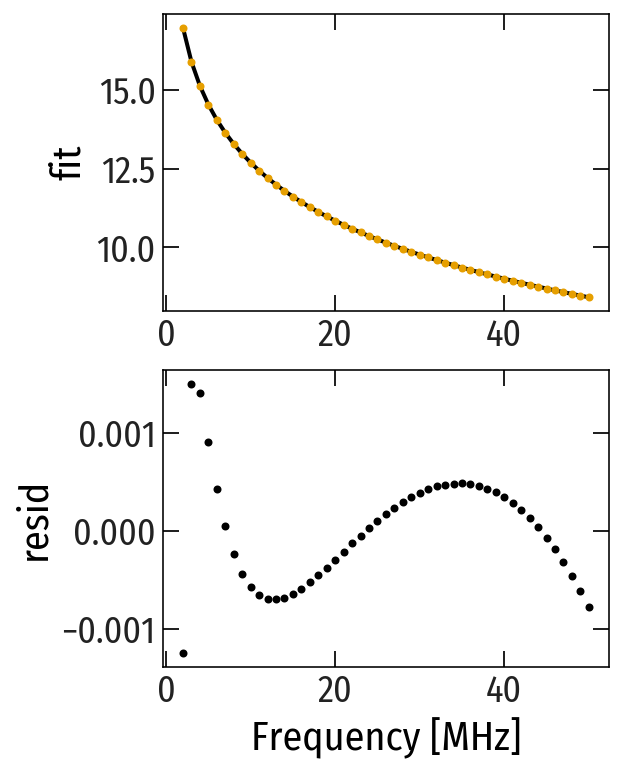

In [10]:
fit(high_latitude_pixels[30], plot=True)

In [11]:
T_cmbs = []

for p in high_latitude_pixels:
    T, Terr = fit(p)
    if Terr < 1e6:
        T_cmbs.append(T)

T_cmbs = np.array(T_cmbs)

In [12]:
np.mean(T_cmbs), np.std(T_cmbs) / np.sqrt(len(high_latitude_pixels))

(0.8188350060803629, 3.5586370809971535)

Text(0.5, 0, '$T_b$ [K]')

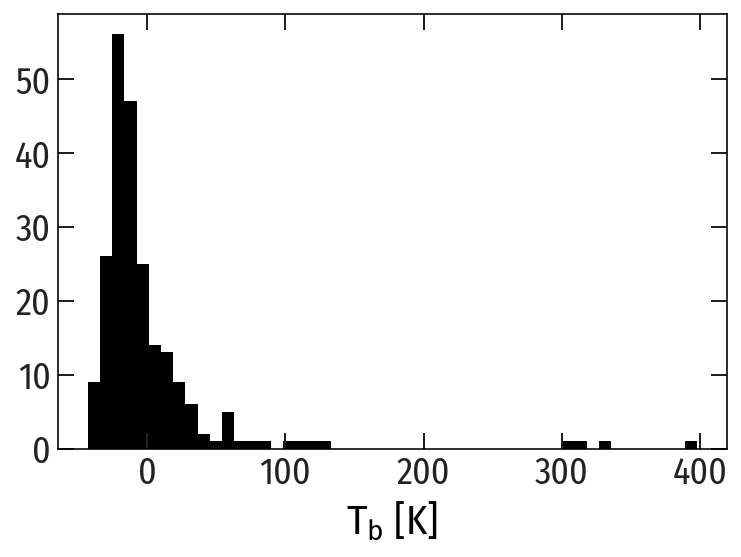

In [13]:
plt.hist(T_cmbs, bins=50)
plt.xlabel("$T_b$ [K]")
# plt.xlim(-200,200)
# plt.yscale("log")

* common Tcmb
* better foreground model (extend power law)